In [1]:
from pathlib import Path
import pandas as pd
import re
base_dir = Path('static_fits')

re_data = re.compile(r'static_fits/(3T|7T)/sub-(\d{,3})/(\d)/([a-z_]+)/all_parameters.csv')

datadict = {}

for idx, fp in enumerate(base_dir.rglob('all_parameters.csv')):
    # print(fp)
    datadict[re_data.match(str(fp)).groups()] = pd.read_csv(fp, index_col=0)['mean']
    if not idx % 100:
        print(idx)
# tmp

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800


In [2]:
df = pd.DataFrame.from_dict(datadict, orient="index")
df.index = pd.MultiIndex.from_tuples(df.index, names=["field", "subject", "block", "method"])
df = df.reorder_levels(["field", "method", "block", "subject"])
block_map = {
    '0': "0_REST",
    '1': "1_TASK",
    '2': "2_REST",
    '3': "3_TASK",
    '4': "4_REST",
}

df = df.rename(index=block_map, level="block")
df = df.sort_index()
df

Ala       Asc       Asp        Cr  \
field method     block  subject                                           
3T    basis_lw   0_REST 001      0.000000  1.019781  3.304165  4.330030   
                        002      0.000000  1.058764  3.481265  4.337142   
                        003      0.038091  1.023396  3.469693  4.350084   
                        004      0.000000  1.000355  3.291060  4.491911   
                        005      0.027069  1.038832  3.448613  4.407773   
...                                   ...       ...       ...       ...   
7T    preproc_lw 4_REST 124      0.000000  1.043492  3.493271  4.403386   
                        125      0.000000  1.051237  3.528879  4.444498   
                        126      0.000000  1.018173  3.381091  4.412289   
                        127      0.029315  1.050018  3.369902  4.410416   
                        128      0.000000  1.026102  3.504134  4.476184   

                                     GABA       GPC       GSH       Glc  \
field method     block  subject                                           
3T    basis_lw   0_REST 001      0.980733  0.521613  1.002401  0.703478   
                        002      0.876562  0.496649  1.038436  0.528644   
                        003      0.971222  0.568882  1.072577  0.549395   
                        004      1.056256  0.496969  1.047232  0.661075   
                        005      0.983155  0.525904  1.036410  0.585965   
...                                   ...       ...       ...       ...   
7T    preproc_lw 4_REST 124      0.965971  0.507103  1.051610  0.605626   
                        125      1.053551  0.515857  1.035963  0.641514   
                        126      1.006592  0.533186  1.043489  0.600070   
                        127      0.967572  0.532293  1.040176  0.585621   
                        128      0.937881  0.511157  1.060819  0.606851   

                                      Gln       Glu  ...      sIns   gamma_0  \
field method     block  subject                      ...                       
3T    basis_lw   0_REST 001      2.814905  8.511637  ...  0.265078  0.407688   
                        002      2.719620  8.605047  ...  0.272359  0.211879   
                        003      2.734893  8.650014  ...  0.257171  0.548336   
                        004      2.818675  8.422966  ...  0.271962  0.221268   
                        005      2.767695  8.579530  ...  0.274065  0.673409   
...                                   ...       ...  ...       ...       ...   
7T    preproc_lw 4_REST 124      2.760461  8.556379  ...  0.268800  1.427402   
                        125      2.785499  8.536600  ...  0.270653  1.401692   
                        126      2.752477  8.529704  ...  0.265896  1.351110   
                        127      2.733688  8.507346  ...  0.253074  1.210038   
                        128      2.768099  8.552333  ...  0.268621  1.239706   

                                   sigma_0     eps_0      Phi0      Phi1  \
field method     block  subject                                            
3T    basis_lw   0_REST 001      11.305734 -0.849324  0.027910  0.000097   
                        002      11.392418 -0.871100  0.022076  0.000072   
                        003      11.241306 -0.840250  0.017544  0.000062   
                        004      11.388683 -0.844993  0.022263  0.000075   
                        005      11.120761 -0.849303  0.023064  0.000072   
...                                    ...       ...       ...       ...   
7T    preproc_lw 4_REST 124      20.830134 -2.081549  0.025031  0.000034   
                        125      20.840618 -2.213493  0.024254  0.000031   
                        126      20.835076 -2.115275  0.027356  0.000038   
                        127      20.857893 -2.165193  0.028786  0.000038   
                        128      20.841969 -2.191218  0.023214  0.000028   

                                 B_real_0  B_imag_0  B_r

Now for the "dangerous" bit. We need to copy the results of the unbroadened basis for the stimulation blocks into the basis_lw entries.

In [14]:
task_blocks = ["1_TASK", "3_TASK"]

src = df.loc[(slice(None), "default", task_blocks, slice(None)), :].copy()

src.index = pd.MultiIndex.from_arrays(
    [
        src.index.get_level_values("field"),
        ["basis_lw"] * len(src),
        src.index.get_level_values("block"),
        src.index.get_level_values("subject"),
    ],
    names=df.index.names,
)

df.loc[src.index] = src

Bias was calculated by evaluating the mean of the TASK blocks as a percentage change from the mean of the REST blocks on a participant by participant basis.

In [17]:
# Map each block to its condition
condition_map = {
    "0_REST": "REST",
    "1_TASK": "TASK",
    "2_REST": "REST",
    "3_TASK": "TASK",
    "4_REST": "REST",
}

df2 = df.rename(index=condition_map, level="block")

# Average over blocks, preserving the other index levels
df_mean = (
    df2
    .groupby(level=["field", "method", "block", "subject"])
    .mean()
)

df_mean

Ala       Asc       Asp        Cr  \
field method     block subject                                           
3T    basis_lw   REST  001      0.051237  1.018061  3.373022  4.369998   
                       002      0.000000  1.039360  3.371394  4.370778   
                       003      0.012697  1.040511  3.472520  4.312198   
                       004      0.000000  0.961082  3.365205  4.430745   
                       005      0.054333  1.097030  3.440270  4.362027   
...                                  ...       ...       ...       ...   
7T    preproc_lw TASK  124      0.000000  1.020200  3.466410  4.481314   
                       125      0.028513  1.029370  3.426763  4.430506   
                       126      0.018442  1.003087  3.423650  4.439714   
                       127      0.045545  1.002588  3.453869  4.481458   
                       128      0.014741  1.034922  3.456364  4.408241   

                                    GABA       GPC       GSH       Glc  \
field method     block subject                                           
3T    basis_lw   REST  001      0.981102  0.525073  1.015312  0.673055   
                       002      0.915530  0.547656  1.024437  0.577076   
                       003      0.974418  0.556719  1.037983  0.593391   
                       004      0.923236  0.505883  1.058064  0.660295   
                       005      0.967007  0.543137  1.019783  0.579318   
...                                  ...       ...       ...       ...   
7T    preproc_lw TASK  124      0.980710  0.498650  1.028616  0.645870   
                       125      0.966648  0.513632  1.046673  0.590203   
                       126      1.024929  0.519261  1.037927  0.622507   
                       127      0.964532  0.514127  1.049161  0.621086   
                       128      0.938383  0.523338  1.032799  0.617716   

                                     Gln       Glu  ...      sIns   gamma_0  \
field method     block subject                      ...                       
3T    basis_lw   REST  001      2.768720  8.514144  ...  0.265521  0.345433   
                       002      2.728477  8.566208  ...  0.270385  0.230634   
                       003      2.751533  8.593508  ...  0.273677  0.303669   
                       004      2.726061  8.603829  ...  0.265362  0.288548   
                       005      2.759333  8.603926  ...  0.272073  0.491886   
...                                  ...       ...  ...       ...       ...   
7T    preproc_lw TASK  124      2.754133  8.531139  ...  0.259168  1.108953   
                       125      2.737114  8.552622  ...  0.263550  1.256707   
                       126      2.758365  8.557144  ...  0.261798  1.255192   
                       127      2.777006  8.556828  ...  0.279063  1.323254   
                       128      2.706213  8.535932  ...  0.259527  1.286180   

                                  sigma_0     eps_0      Phi0      Phi1  \
field method     block subject                                            
3T    basis_lw   REST  001      11.320060 -0.823185  0.024900  0.000090   
                       002      11.380774 -0.839316  0.022565  0.000079   
                       003      11.342715 -0.875608  0.026508  0.000085   
                       004      11.343160 -0.825753  0.024196  0.000076   
                       005      11.251283 -0.844988  0.023387  0.000074   
...                                   ...       ...       ...       ...   
7T    preproc_lw TASK  124      20.913214 -2.246033  0.025332  0.000032   
                       125      20.867236 -2.171821  0.030879  0.000041   
                       126      20.840610 -2.138687  0.025596  0.000033   
                       127      20.848167 -2.155120  0.026073  0.000035   
                       128      20.845835 -2.131453  0.028427  0.000040   

                                B_real_0  B_imag_0  B_real_1  B_imag_1  
field method     block subject    

In [19]:
import numpy as np
rest = df_mean.xs("REST", level="block")
task = df_mean.xs("TASK", level="block")

rel_change = (task - rest).div(rest).mul(100)
rel_change = rel_change.replace([np.inf, -np.inf], np.nan)
rel_change

Ala       Asc       Asp        Cr       GABA  \
field method     subject                                                        
3T    basis_lw   001      -88.634450 -6.128923 -0.814041 -0.919609   0.140094   
                 002             NaN  0.824871  0.413355  0.077936  12.766278   
                 003      296.693984 -2.559975 -1.279973  1.172204  -5.319721   
                 004             NaN  5.513490  2.473759 -2.065301  -1.615669   
                 005     -100.000000  0.110446 -1.113183  2.850427   0.435450   
...                              ...       ...       ...       ...        ...   
7T    preproc_lw 124     -100.000000 -2.920672  1.118804  1.337522  -0.219671   
                 125       -4.599993  0.821170 -1.795183 -0.216594  -2.818297   
                 126      155.394395 -1.098154  0.061486 -0.164678   1.808647   
                 127      366.081988 -3.120043  1.038289  0.727490   2.247249   
                 128      -41.625813  1.637781  0.451809 -0.663433  -3.513510   

                               GPC       GSH       Glc       Gln       Glu  \
field method     subject                                                     
3T    basis_lw   001      5.521785  8.298993 -7.286336 -1.081724  0.341846   
                 002     -1.168671  1.916357  8.806355  0.208154 -0.303040   
                 003     -2.403714 -0.134151  2.247081  0.327972  0.121157   
                 004      2.813308  2.332020 -8.798968 -4.341690  0.594168   
                 005     -3.429299  1.106465 -0.877203 -1.951779  0.282952   
...                            ...       ...       ...       ...       ...   
7T    preproc_lw 124     -2.759322 -2.044084  3.436306  0.366977 -0.026554   
                 125     -0.088093  0.502824 -3.058439 -1.264484 -0.244673   
                 126      0.564280 -1.004487  0.433604 -1.006741  0.150496   
                 127     -0.164152  0.443639  2.367452  1.193533  0.228504   
                 128      0.367836 -1.498463  3.551219 -1.930544 -0.316878   

                          ...      sIns     gamma_0   sigma_0     eps_0  \
field method     subject  ...                                             
3T    basis_lw   001      ...  1.242329 -100.000000 -0.073191  4.506482   
                 002      ... -1.753537  -99.882554 -0.615765  1.819910   
                 003      ...  1.009911  -93.704623 -0.348589 -5.024978   
                 004      ...  1.311249 -100.000000 -0.146036  2.564463   
                 005      ... -4.217288  -68.850186  0.066157 -4.103018   
...                       ...       ...         ...       ...       ...   
7T    preproc_lw 124      ... -2.322304  -16.166645  0.315242  5.704306   
                 125      ... -2.213339   -2.980655  0.138636 -1.451598   
                 126      ... -2.375587   -8.437186  0.179581  0.305101   
                 127      ...  6.933660    9.144149 -0.113020  0.079461   
                 128      ... -2.565530    2.860555  0.050634 -2.544849   

                               Phi0       Phi1   B_real_0   B_imag_0  \
field method     subject                                               
3T    basis_lw   001      -5.271958 -13.725625 -31.969115  23.747920   
                 002     -12.516990 -17.409540 -33.935409 -49.211632   
                 003     -23.506511 -22.797263  -8.116307 -51.749047   
                 004      -3.768661   9.070368   9.626843 -47.639880   
                 005      -5.503819   5.175435   5.168316 -32.408737   
...                             ...        ...        ...        ...   
7T    preproc_lw 124      -6.826654 -13.373576   0.502382  24.045995   
                 125      13.979272  18.813985  36.665940  -1.830082   
                 126      -4.994471  -6.489386  -9.577537  29.295458   
                 127      -4.106231  -1.702883 -13.832008 -19.852148   
                 128      11.568608  23.414697  18.322104 -11.777878   

                            B_real_1     B_imag_1  

In [20]:
keep = [
    "Asc", "Asp", "GABA", "Glc", "Gln", "Glu", "GSH", "Ins",
    "Lac", "PEth", "sIns", "Tau", "tCho", "tCr", "tNAA"
]

rel_change_sub = rel_change.copy()

rel_change_sub = rel_change_sub.assign(
    tNAA=rel_change_sub["NAA"] + rel_change_sub["NAAG"],
    tCho=rel_change_sub["GPC"] + rel_change_sub["PCh"],
    tCr=rel_change_sub["Cr"] + rel_change_sub["PCr"],
)

rel_change_sub = rel_change_sub.loc[:, keep]

In [21]:
# Summary statistics across subjects
mean = rel_change_sub.groupby(level=["field", "method"]).mean()
sd = rel_change_sub.groupby(level=["field", "method"]).std()

# Cohen's d (one-sample effect size against 0)
cohens_d = mean / sd

summary = pd.concat(
    {
        "Mean": mean,
        "SD": sd,
        "Cohens d": cohens_d,
    },
    names=["value_type"],
)

summary = summary.reorder_levels(["field", "method", "value_type"]).sort_index()
summary

Asc       Asp      GABA       Glc       Gln  \
field method     value_type                                                     
3T    basis_lw   Cohens d    0.072093  0.077033 -0.052675 -0.128117 -0.230312   
                 Mean        0.375651  0.165626 -0.308586 -0.838516 -0.438089   
                 SD          5.210665  2.150074  5.858351  6.544944  1.902154   
      default    Cohens d    0.072178  0.076075 -0.056838 -0.130766 -0.234764   
                 Mean        0.376162  0.163533 -0.332927 -0.856457 -0.446606   
                 SD          5.211620  2.149635  5.857505  6.549535  1.902363   
      preproc_lw Cohens d    0.078336  0.025316  0.046279 -0.039715 -0.085637   
                 Mean        0.426862  0.056891  0.288030 -0.272760 -0.166853   
                 SD          5.449110  2.247265  6.223829  6.867944  1.948375   
7T    basis_lw   Cohens d    0.345182  0.330487 -0.144901 -0.377812 -0.102610   
                 Mean        0.773793  0.451167 -0.423786 -1.423124 -0.095116   
                 SD          2.241693  1.365157  2.924659  3.766755  0.926966   
      default    Cohens d    0.341751  0.324876 -0.147513 -0.379831 -0.110892   
                 Mean        0.766028  0.443464 -0.431391 -1.430599 -0.102785   
                 SD          2.241480  1.365025  2.924423  3.766409  0.926897   
      preproc_lw Cohens d   -0.029722  0.194293  0.089724  0.035289 -0.133617   
                 Mean       -0.079900  0.285242  0.287479  0.156948 -0.136757   
                 SD          2.688284  1.468107  3.204056  4.447472  1.023504   

                                  Glu       GSH       Ins       Lac      PEth  \
field method     value_type                                                     
3T    basis_lw   Cohens d    0.347549  0.172471  0.267899  0.106893  0.008268   
                 Mean        0.297029  0.524621  0.154353  0.614792  0.043755   
                 SD          0.854638  3.041796  0.576161  5.751483  5.291845   
      default    Cohens d    0.349610  0.173915  0.269089  0.107058  0.005074   
                 Mean        0.299689  0.528858  0.154737  0.615747  0.026882   
                 SD          0.857209  3.040899  0.575040  5.751512  5.298079   
      preproc_lw Cohens d    0.069795  0.031364 -0.025513  0.018869  0.081332   
                 Mean        0.063528  0.099578 -0.015058  0.115035  0.459495   
                 SD          0.910209  3.174946  0.590211  6.096577  5.649654   
7T    basis_lw   Cohens d    1.163669  0.513008  1.212897  0.341439 -0.301785   
                 Mean        0.318144  0.528687  0.299798  0.644807 -0.834704   
                 SD          0.273397  1.030564  0.247175  1.888501  2.765888   
      default    Cohens d    1.135621  0.505566  1.181859  0.337339 -0.304559   
                 Mean        0.310451  0.520977  0.292106  0.637033 -0.842294   
                 SD          0.273376  1.030482  0.247158  1.888410  2.765619   
      preproc_lw Cohens d   -0.072325  0.101310 -0.071227 -0.014869  0.207577   
                 Mean       -0.023554  0.110631 -0.020936 -0.030673  0.662185   
                 SD          0.325667  1.092003  0.293938  2.062793  3.190066   

                                 sIns       Tau      tCho       tCr      tNAA  
field method     value_type                                                    
3T    basis_lw   Cohens d    0.066418  0.113377  0.346808  0.471479  0.449050  
                 Mean        0.258085  0.441315  0.916671  0.455647  0.910322  
                 SD          3.885762  3.892453  2.643168  0.966420  2.027218  
      default    Cohens d    0.065635  0.115220  0.349366  0.473027  0.451168  
                 Mean        0.255025  0.449218  0.926103  0.459918  0.920460  
                 SD          3.885489  3.898766  2.650808  0.972286  2.040171  
      preproc_lw Cohens d    0.031397  0.041025  0.037229 -0.029124  0.108945  
                 Mean        0.127943  0.171100  0.106725 -0.033555  0.2

In [43]:
for method in ("default", "preproc_lw", "basis_lw"):
    for field in ("3T", "7T"):
        print(f'{field} {method}:{summary.loc[(field, method, "Mean"), "Glu"]: 0.02f} ({np.abs(summary.loc[(field, method, "Cohens d"), "Glu"]):0.02f})')


3T default: 0.30 (0.35)
7T default: 0.31 (1.14)
3T preproc_lw: 0.06 (0.07)
7T preproc_lw:-0.02 (0.07)
3T basis_lw: 0.30 (0.35)
7T basis_lw: 0.32 (1.16)


In [22]:
long_df = (
    summary
    .stack()
    .rename("value")
    .reset_index()
)
long_df = long_df.rename(columns={"level_3": "Metabolite"})
long_df

,field,method,value_type,Metabolite,value
0,3T,basis_lw,Cohens d,Asc,0.072093
1,3T,basis_lw,Cohens d,Asp,0.077033
2,3T,basis_lw,Cohens d,GABA,-0.052675
3,3T,basis_lw,Cohens d,Glc,-0.128117
4,3T,basis_lw,Cohens d,Gln,-0.230312
...,...,...,...,...,...
265,7T,preproc_lw,SD,sIns,2.058423
266,7T,preproc_lw,SD,Tau,1.482434
267,7T,preproc_lw,SD,tCho,1.276327
268,7T,preproc_lw,SD,tCr,0.574355


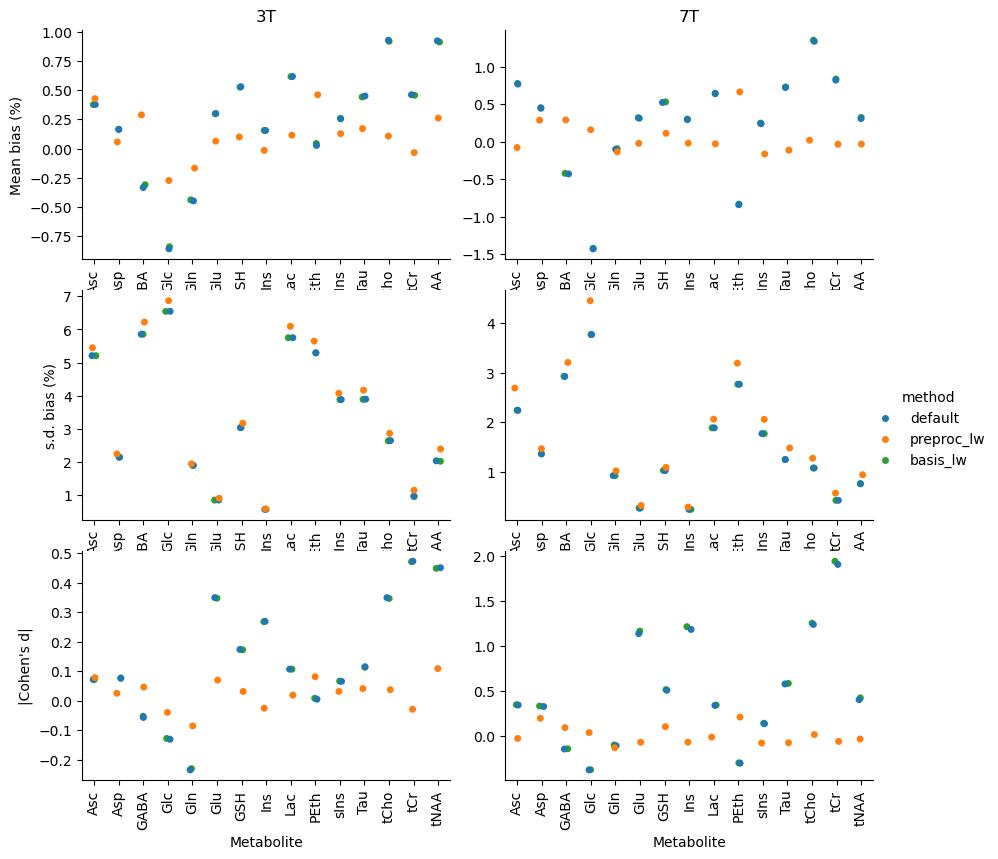

In [ ]:
import matplotlib.colors  # important: force submodule registration
import seaborn as sns

colors = {
    'default': '#F8766D',
    'preproc_lw': '#00BA39',
    'basis_lw': '#609CFF'
}

effect_plot2 = sns.catplot(
    data=long_df,
    kind="strip",
    x="Metabolite",
    hue="method",
    y="value",
    col="field",
    row="value_type",
    col_order=["3T", "7T"],
    row_order=["Mean", "SD", "Cohens d"],
    sharey=False,
    sharex=False,
    hue_order=["default", "preproc_lw", "basis_lw"],
    order=[
        "Asc", "Asp", "GABA", "Glc", "Gln", "Glu", "GSH", "Ins",
        "Lac", "PEth", "sIns", "Tau", "tCho", "tCr", "tNAA"
    ],
)

_=effect_plot2.set_xticklabels(rotation=90)
effect_plot2.figure.set_size_inches(10,8)

_ = effect_plot2.axes.flat[0].set(ylabel="Mean bias (%)")
_ = effect_plot2.axes.flat[2].set(ylabel="s.d. bias (%)")
_ = effect_plot2.axes.flat[4].set(ylabel="|Cohen's d|")

for ax in effect_plot2.axes.flat[2:]:
    ax.set(title="")
_ = effect_plot2.axes.flat[0].set(title="3T")
_ = effect_plot2.axes.flat[1].set(title="7T")

effect_plot2.savefig("figures/static_effect_size_per_met_baseline_poly.png", dpi=600, bbox_inches="tight") 

In [25]:
long_df

,field,method,value_type,Metabolite,value
0,3T,basis_lw,Cohens d,Asc,0.072093
1,3T,basis_lw,Cohens d,Asp,0.077033
2,3T,basis_lw,Cohens d,GABA,-0.052675
3,3T,basis_lw,Cohens d,Glc,-0.128117
4,3T,basis_lw,Cohens d,Gln,-0.230312
...,...,...,...,...,...
265,7T,preproc_lw,SD,sIns,2.058423
266,7T,preproc_lw,SD,Tau,1.482434
267,7T,preproc_lw,SD,tCho,1.276327
268,7T,preproc_lw,SD,tCr,0.574355


In [32]:
outputdf = long_df.copy()

# percentage for Mean/SD
cd_index = outputdf.value_type=="Cohens d"
outputdf.loc[cd_index, "value"] = outputdf.loc[cd_index, "value"].abs()
# to_plot_cd2.loc[~cd_index, "value"] = to_plot_cd2.loc[~cd_index, "value"] * 100.0

outputdf = outputdf.replace('basis_lw', 'basis lw matching')
outputdf = outputdf.replace('preproc_lw', 'preproc lw matching')
outputdf = outputdf.replace('default', 'default analysis')


outputdf.to_csv('figures/fsl_static_fitting_results.csv')
outputdf

,field,method,value_type,Metabolite,value
0,3T,basis lw matching,Cohens d,Asc,0.072093
1,3T,basis lw matching,Cohens d,Asp,0.077033
2,3T,basis lw matching,Cohens d,GABA,0.052675
3,3T,basis lw matching,Cohens d,Glc,0.128117
4,3T,basis lw matching,Cohens d,Gln,0.230312
...,...,...,...,...,...
265,7T,preproc lw matching,SD,sIns,2.058423
266,7T,preproc lw matching,SD,Tau,1.482434
267,7T,preproc lw matching,SD,tCho,1.276327
268,7T,preproc lw matching,SD,tCr,0.574355
